## Datos sinteticos
## Libreria SDv


In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
import sdv
import sdmetrics

In [3]:
# Importamos sublibrerías para la generación de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [4]:
# Importamos sublibrerías para la evaluación de los datos
from sdmetrics.reports.single_table import QualityReport

In [5]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [6]:
# Crear una tabla de datos REAL como base para la
# generación de Datos Sintéticos.
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [17, 18, 19, 25, 32, 42, 70, 28, 23, 22],
        "ingres_mensual" : [1800, 2000, 2500, 18000, 35000, 7000, 15000, 4000, 5000, 6000], 
        "ciudad": ["Potrero Nuevo", "Atoyac", "Cuichapa", "Córdoba", "Cuitláhuac", "Orizaba", "Paraje", "Yanga", "Tierra blanca", "Calcahualco"]
    }
)

In [7]:
dfClientes

,cliente_id,edad,ingres_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,18000,Córdoba
4,5,32,35000,Cuitláhuac
5,6,42,7000,Orizaba
6,7,70,15000,Paraje
7,8,28,4000,Yanga
8,9,23,5000,Tierra blanca
9,10,22,6000,Calcahualco


### Obtener los metadata del Dataframe generado

In [8]:
# Creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [9]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [10]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingres_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

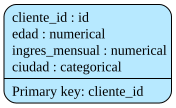

In [11]:
metadata.visualize()

### Entrenar el modelo de datos sinteticos
*sinthetisizer en el encargadi de generar datos sinteticos*

In [12]:
# le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\100043016\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\100043016\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [13]:
# entrenamos el sintetizador con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [14]:
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [15]:
dfClientes_falsos.head()

,cliente_id,edad,ingres_mensual,ciudad
0,16169768,40,24728,Paraje
1,4918803,19,2398,Paraje
2,1900081,21,3403,Córdoba
3,531516,20,2046,Cuitláhuac
4,10211768,36,11593,Yanga


In [16]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cliente_id      200 non-null    int64 
 1   edad            200 non-null    int64 
 2   ingres_mensual  200 non-null    int64 
 3   ciudad          200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [17]:
dfClientes_falsos.describe()

,cliente_id,edad,ingres_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.060000,8594.955000
std,4.707538e+06,12.535233,8984.121561
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2053.500000
50%,9.212590e+06,20.000000,4457.000000
75%,1.279456e+07,30.250000,12333.250000
max,1.677377e+07,70.000000,35000.000000


### Evaluamos los datos para validar
1. Parecido entre las columnas (Columns Shapes Score)
2. Parecido entre las relaciones de las columnas (Evaluating column per Trends)
3. Evaluacion del dataset general

In [18]:
## Evaluamos la calidad de los datos
# Creamos una instancia de QualityRport
reporte = QualityReport()

### Puntos de referencia

| Score | Interpretación |
|-------|----------------|
| 1     | Idénticas      |
| 0.9   | Muy similar    |
| 0.7   | Similar        |
| 0.6   | Diferencias visibles |
| < 0.5 | Muy diferentes |

In [19]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 271.59it/s]|
Column Shapes Score: 81.83%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 108.92it/s]|
Column Pair Trends Score: 31.25%

Overall Score (Average): 56.54%

